# Clustering Analysis

This notebook is intended to showcase downstream modeling (via clustering) for extracted data. We make use of predicted probabilities from our probes or next token predictions to do so.

In [52]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
         
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from analysis.loaders import (
    load_combined_judgements, load_extraction, load_ground_truth, load_trained_probe, load_activations,
    cached_match, load_synthetic_responses, load_synthetic_activations, load_synthetic_layer_outputs,
)
from scholarlm.utils.unit_conversion import apply_unit_conversion
from experiments.run_extraction import load_dataset_config
import paths

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.title_fontsize": 9,
    "axes.linewidth": 0.6,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "legend.frameon": False,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.format": "pdf", "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

FIGURES_DIR = "../figures/clustering/"
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# ── Parameters ───────────────────────────────────────────────────────────────
DATASET = 'pond'
EXTRACTION_MODEL = 'gemma-3-27b'
EXTRACTION_DATE = '2026_05_05'
JUDGE_MODEL = 'llama-3.1-8b'
JUDGE_DATE = '2026_05_06'

## Load ground truth and extracted data

In [95]:
config  = load_dataset_config(DATASET)
gt_df = load_ground_truth(config)
records = load_extraction(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE)
ext_df  = pd.DataFrame(records)

# Move to common units:
gt_df  = apply_unit_conversion(gt_df, config.unit_conversion_table)
ext_df  = apply_unit_conversion(ext_df, config.unit_conversion_table)

# Identify entities for the ground truth
gt_entity_columns = ['document_id', 'name', 'location', 'ecosystem']
gt_df['entity_id'] = gt_df.groupby(gt_entity_columns, dropna=False).ngroup()

# Pivot to wide format
gt_pivoted = gt_df.pivot_table(
    index=['entity_id'], 
    columns='attribute', 
    values='converted_value',
    aggfunc='first'
).reset_index()

ext_pivoted = ext_df.pivot_table(
    index=['entity_id'], 
    columns='attribute', 
    values='converted_value',
    aggfunc='first'
).reset_index()

gt_pivoted = gt_pivoted.set_index('entity_id')
ext_pivoted = ext_pivoted.set_index('entity_id')
gt_pivoted.columns.name = None
ext_pivoted.columns.name = None

# Summary:
gt_stats = gt_pivoted.describe().T
gt_stats['missing'] = gt_pivoted.isna().sum()
print("--- Ground Truth Summary ---")
print(gt_stats[['mean', 'min', 'max', 'missing']])

ext_stats = ext_pivoted.describe().T
ext_stats['missing'] = ext_pivoted.isna().sum()
print("\n--- Extraction Summary ---")
print(ext_stats[['mean', 'min', 'max', 'missing']])

--- Ground Truth Summary ---
                          mean      min       max  missing
chla                 52.355680    0.000    1704.0      780
max_depth             2.116723    0.090       9.0      676
ph                    7.405768    3.800      10.3      664
surface_area      21348.491692    0.003  190000.0      259
tn                 2416.966372  247.600   31200.0      973
tp                 7291.362835    3.200  490000.0      744
vegetation_cover     46.895556    0.000     100.0     1019

--- Extraction Summary ---
                          mean      min           max  missing
chla              1.215437e+04 -0.65400  7.080700e+05      862
max_depth         1.218075e+01  0.00650  8.200000e+02      586
ph                8.930634e+00  0.04500  4.520000e+02      752
surface_area      6.029831e+08  0.00057  2.574380e+11      203
tn                1.328585e+05  0.30000  3.613000e+06      948
tp                1.676570e+04  0.02000  9.380000e+05      758
vegetation_cover  5.505901e+02

In [96]:
# Drop columns with too many missing entries
drops = ['tn', 'vegetation_cover']
gt_pivoted.drop(columns=drops, inplace=True)
ext_pivoted.drop(columns=drops, inplace=True)

X_gt = gt_pivoted.to_numpy()
X_ext = ext_pivoted.to_numpy()

# Preprocess
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
scaler = StandardScaler()

X_gt = knn_imputer.fit_transform(X_gt)
X_gt = scaler.fit_transform(X_gt)

X_ext = knn_imputer.transform(X_ext)
X_ext = scaler.transform(X_ext)

## Load predicted probability

In [43]:
judge_df = pd.DataFrame(load_combined_judgements(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE))

pd_data  =  load_trained_probe('nfix', JUDGE_MODEL) # Could alternatively use the probe trained on nfix here...
top_k    = pd_data['top_k_heads']
act = load_activations(
    DATASET, EXTRACTION_MODEL, EXTRACTION_DATE, JUDGE_MODEL, JUDGE_DATE
)

mids = judge_df.measurement_id

X = np.concatenate([
    np.stack([
        np.array(act[str(mid)], dtype=np.float32)[l, h, :]
        for mid in mids
    ], axis=0)
    for l, h in top_k
], axis=1)

judge_df['p_probe'] = pd_data['probe'].predict_proba(X)[:, 1]

In [115]:
# Pivot to wide format
judge_ntp_pivoted = judge_df.pivot_table(
    index=['entity_id'], 
    columns='attribute', 
    values=f'judgement_p_true_{JUDGE_MODEL}',
    aggfunc='first'
).reset_index()

judge_probe_pivoted = judge_df.pivot_table(
    index=['entity_id'], 
    columns='attribute', 
    values='p_probe',
    aggfunc='first'
).reset_index()

judge_ntp_pivoted = judge_ntp_pivoted.set_index('entity_id')
judge_probe_pivoted = judge_probe_pivoted.set_index('entity_id')
judge_ntp_pivoted.columns.name = None
judge_probe_pivoted.columns.name = None

judge_ntp_pivoted = judge_ntp_pivoted.loc[ext_pivoted.index]
judge_probe_pivoted = judge_probe_pivoted.loc[ext_pivoted.index]

judge_ntp_pivoted.drop(columns=drops, inplace=True)
judge_probe_pivoted.drop(columns=drops, inplace=True)

# Take entity level probs as product across columns 
ntp_probs = judge_ntp_pivoted.prod(axis=1, min_count=1).to_numpy()
probe_probs = judge_probe_pivoted.prod(axis=1, min_count=1).to_numpy()
ntp_probs= np.nan_to_num(ntp_probs, nan=0.0)
probe_probs = np.nan_to_num(probe_probs, nan=0.0)

## Clustering
Starting with the ground truth dataset and then comparing to the extracted. 

In [123]:
def centroid_matching_distance(A, B, metric='euclidean'):
    """
    A, B:       arrays of shape (k, d) and (m, d) — cluster centers
    metric:     distance metric to use
    
    Returns:
        dist:   sum of matched distances
    """
    # Optimal assignment
    D = cdist(A, B, metric=metric)
    row_ind, col_ind = linear_sum_assignment(D, maximize=False)
    matched_distances = D[row_ind, col_ind]
    dist = matched_distances.mean()
    return dist

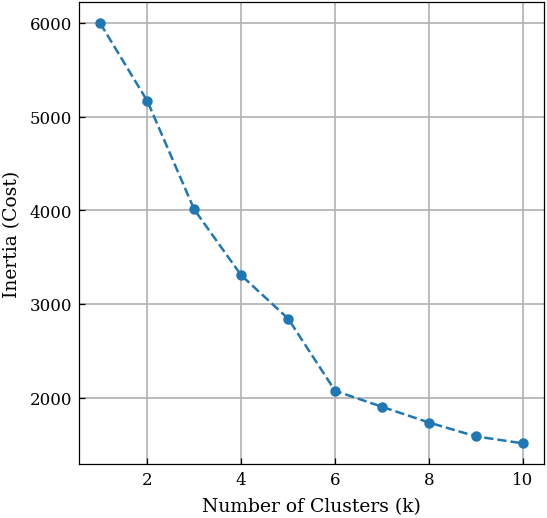

In [109]:
# Calculate inertia for k values from 1 to 10
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_gt)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(4, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Cost)')
plt.grid(True)
plt.show()

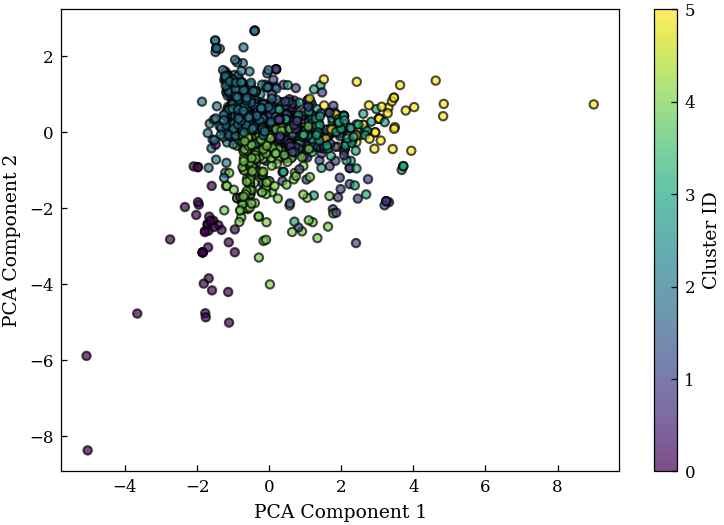

In [110]:
n_clusters = 6

# Fit final model
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
gt_labels = kmeans.fit_predict(X_gt)
gt_centers = kmeans.cluster_centers_

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_gt)

# Plot the clusters
plt.figure(figsize=(6, 4))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', edgecolors='k', alpha=0.7)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [126]:
gamma_vals = np.linspace(1.0,10,101)

ntp_distances = np.empty(len(gamma_vals))
probe_distances = np.empty(len(gamma_vals))

for i, gamma in enumerate(gamma_vals):
    ntp_kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    ntp_labels = ntp_kmeans.fit_predict(X_ext, sample_weight = ntp_probs ** gamma)
    ntp_centers = ntp_kmeans.cluster_centers_
    ntp_distances[i] = centroid_matching_distance(gt_centers, ntp_centers)

    probe_kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    probe_labels = probe_kmeans.fit_predict(X_ext, sample_weight = probe_probs ** gamma)
    probe_centers = probe_kmeans.cluster_centers_
    probe_distances[i] = centroid_matching_distance(gt_centers, probe_centers)

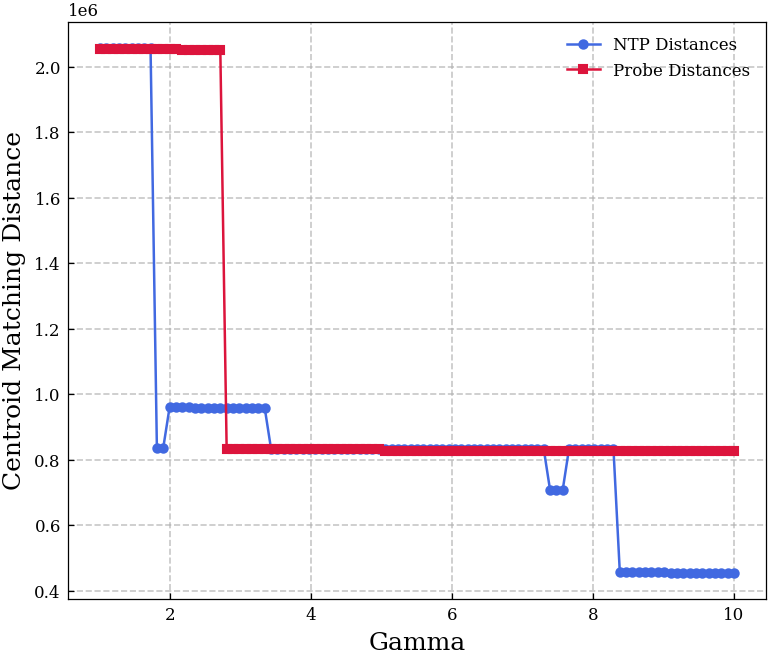

In [127]:
# Create the plot
plt.figure(figsize=(6, 5))
plt.plot(gamma_vals, ntp_distances, marker='o', label='NTP Distances', color='royalblue')
plt.plot(gamma_vals, probe_distances, marker='s', label='Probe Distances', color='crimson')

# Add labels and title
plt.xlabel('Gamma', fontsize=12)
plt.ylabel('Centroid Matching Distance', fontsize=12)

# Add styling
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Show the plot
plt.show()